# Cattle Muzzle Individual Dataset Analysis

This notebook provides a comprehensive analysis of the Cattle Muzzle Individual dataset. Cattle muzzle print patterns are unique biometrics (analogous to human fingerprints) that can be used for individual cattle identification. This notebook covers:

- Dataset Importing & Loading (supports both flat directories and pre-split train/val/test layouts).
- Cattle Profiling: Mapping all cattle IDs, counts of images per ID, and identifying the minimum/maximum images per cow.
- Data Visualization: Histogram of the image count distribution and a grid of sample muzzle prints.
- Known/Unknown Separation: Grouping cows based on a threshold of 10 images (cows with < 10 images are unknown, >= 10 are known) and exporting lists to CSVs.
- Duplicate Image Detection: Scanning for exact duplicate files based on MD5 checksums.
- Split Representation Integrity Analysis: Verifying split statistics and integrity.

In [1]:
import os
import hashlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Import and Resolve Dataset

In [2]:
def find_dataset_dir():
    search_roots = ["."]
    kaggle_base = "/kaggle/input"
    if os.path.exists(kaggle_base):
        search_roots.append(kaggle_base)
        
    for root_dir in search_roots:
        for root, dirs, files in os.walk(root_dir):
            dirs[:] = [d for d in dirs if d not in ["Known_Cattle", "Unknown_Cattle", "Known_Split"]]
            cattle_dirs = [d for d in dirs if d.startswith("cattle_")]
            if len(cattle_dirs) > 0:
                return root
                
    exact_kaggle_path = "/kaggle/input/datasets/shubhamjha19/cattle/Cattle Muzzle - DB"
    if os.path.exists(exact_kaggle_path) and os.path.isdir(exact_kaggle_path):
        return exact_kaggle_path
        
    for root_dir in search_roots:
        for root, dirs, files in os.walk(root_dir):
            dirs[:] = [d for d in dirs if d not in ["Known_Cattle", "Unknown_Cattle", "Known_Split"]]
            if any(d in dirs for d in ["Cattle Muzzle - DB", "BeefCattle_Muzzle_Individualized"]):
                for d in dirs:
                    if d in ["Cattle Muzzle - DB", "BeefCattle_Muzzle_Individualized"]:
                        return os.path.join(root, d)
            numeric_dirs = [d for d in dirs if d.isdigit()]
            if len(numeric_dirs) > 5:
                return root
                
    raise FileNotFoundError("Could not locate dataset directory.")

def resolve_dataset_dir(path):
    current = path
    while True:
        items = [i for i in os.listdir(current) if not i.startswith('.')]
        if len(items) == 1 and os.path.isdir(os.path.join(current, items[0])):
            current = os.path.join(current, items[0])
        else:
            break
    return current

actual_dataset = resolve_dataset_dir(find_dataset_dir())
eda_folder = "."
print(f"Resolved Dataset Directory: {actual_dataset}")
print(f"EDA Output Folder: {eda_folder}")

Resolved Dataset Directory: ./BeefCattle_Muzzle_Individualized/BeefCattle_Muzzle_Individualized
EDA Output Folder: .


## 2. Scan and Read Dataset

In [3]:
splits = ["train", "val", "test"]
has_splits = all(os.path.exists(os.path.join(actual_dataset, s)) for s in splits)

image_records = []

if has_splits:
    print("Pre-split dataset layout detected.")
    for split in splits:
        split_path = os.path.join(actual_dataset, split)
        cows = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d)) and not d.startswith('.')])
        for cow in cows:
            cow_path = os.path.join(split_path, cow)
            files = sorted([f for f in os.listdir(cow_path) if os.path.isfile(os.path.join(cow_path, f)) and not f.startswith('.')])
            for f in files:
                image_records.append({
                    "cattle_id": cow,
                    "filename": f,
                    "filepath": os.path.join(cow_path, f),
                    "original_split": split
                })
else:
    print("Flat dataset layout detected. Performing in-memory split.")
    cows = sorted([d for d in os.listdir(actual_dataset) if os.path.isdir(os.path.join(actual_dataset, d)) and not d.startswith('.')])
    random.seed(42)
    for cow in cows:
        cow_path = os.path.join(actual_dataset, cow)
        files = sorted([f for f in os.listdir(cow_path) if os.path.isfile(os.path.join(cow_path, f)) and not f.startswith('.')])
        shuffled_files = list(files)
        random.shuffle(shuffled_files)
        total_files = len(shuffled_files)
        is_known = total_files >= 10
        if is_known:
            train_size = int(0.70 * total_files)
            val_size = int(0.15 * total_files)
            train_files = shuffled_files[:train_size]
            val_files = shuffled_files[train_size:train_size + val_size]
            test_files = shuffled_files[train_size + val_size:]
            for f in train_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "train"})
            for f in val_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "val"})
            for f in test_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "test"})
        else:
            for f in shuffled_files:
                image_records.append({"cattle_id": cow, "filename": f, "filepath": os.path.join(cow_path, f), "original_split": "test"})

df_images = pd.DataFrame(image_records)
print("Total loaded images:", len(df_images))

df_cows = df_images.groupby("cattle_id").size().reset_index(name="image_count")
df_cows = df_cows.sort_values(by="cattle_id", key=lambda x: x.astype(int) if x.str.isdigit().all() else x)
df_cows.to_csv(os.path.join(eda_folder, "cow_image_counts.csv"), index=False)

print("Total unique cows (cattle IDs):", len(df_cows))
for idx, row in df_cows.iterrows():
    print(f"{row['cattle_id']} : {row['image_count']}")

Flat dataset layout detected. Performing in-memory split.
Total loaded images: 4923
Total unique cows (cattle IDs): 268
cattle_0100 : 8
cattle_0200 : 10
cattle_0300 : 17
cattle_0400 : 7
cattle_0500 : 14
cattle_0600 : 19
cattle_0700 : 16
cattle_0800 : 18
cattle_0900 : 12
cattle_1000 : 12
cattle_1100 : 11
cattle_1200 : 11
cattle_1300 : 12
cattle_1400 : 13
cattle_1500 : 6
cattle_1600 : 14
cattle_1700 : 12
cattle_1800 : 22
cattle_1900 : 8
cattle_2000 : 14
cattle_2100 : 4
cattle_2200 : 6
cattle_2220 : 6
cattle_2300 : 22
cattle_2320 : 14
cattle_2400 : 23
cattle_2500 : 33
cattle_2510 : 10
cattle_2600 : 27
cattle_2700 : 17
cattle_2710 : 15
cattle_2740 : 8
cattle_2800 : 24
cattle_2900 : 15
cattle_2930 : 6
cattle_3000 : 15
cattle_3100 : 13
cattle_3200 : 16
cattle_3300 : 13
cattle_3400 : 7
cattle_3420 : 4
cattle_3802 : 8
cattle_3812 : 12
cattle_3814 : 13
cattle_3819 : 19
cattle_3832 : 42
cattle_3842 : 14
cattle_3844 : 15
cattle_3847 : 21
cattle_3852 : 29
cattle_3856 : 16
cattle_4208 : 18
cattle_4

## 3. Minimum and Maximum Cow Image Counts

In [4]:
min_row = df_cows.loc[df_cows["image_count"].idxmin()]
max_row = df_cows.loc[df_cows["image_count"].idxmax()]

print("Cow ID with Minimum Images:", min_row["cattle_id"])
print("Number of Images:", min_row["image_count"])
print("Cow ID with Maximum Images:", max_row["cattle_id"])
print("Number of Images:", max_row["image_count"])

Cow ID with Minimum Images: cattle_2100
Number of Images: 4
Cow ID with Maximum Images: cattle_4613
Number of Images: 70


## 4. Histogram and Sample Images Grid

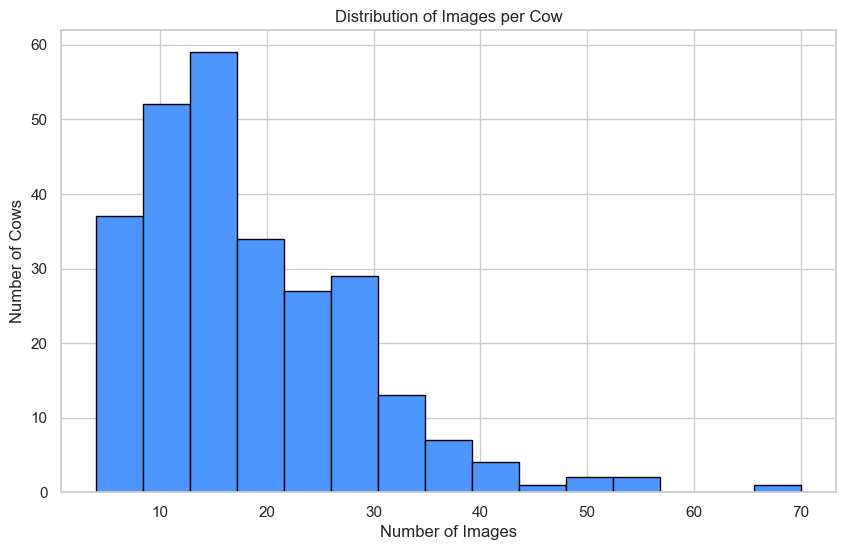

Displaying sample muzzle prints:


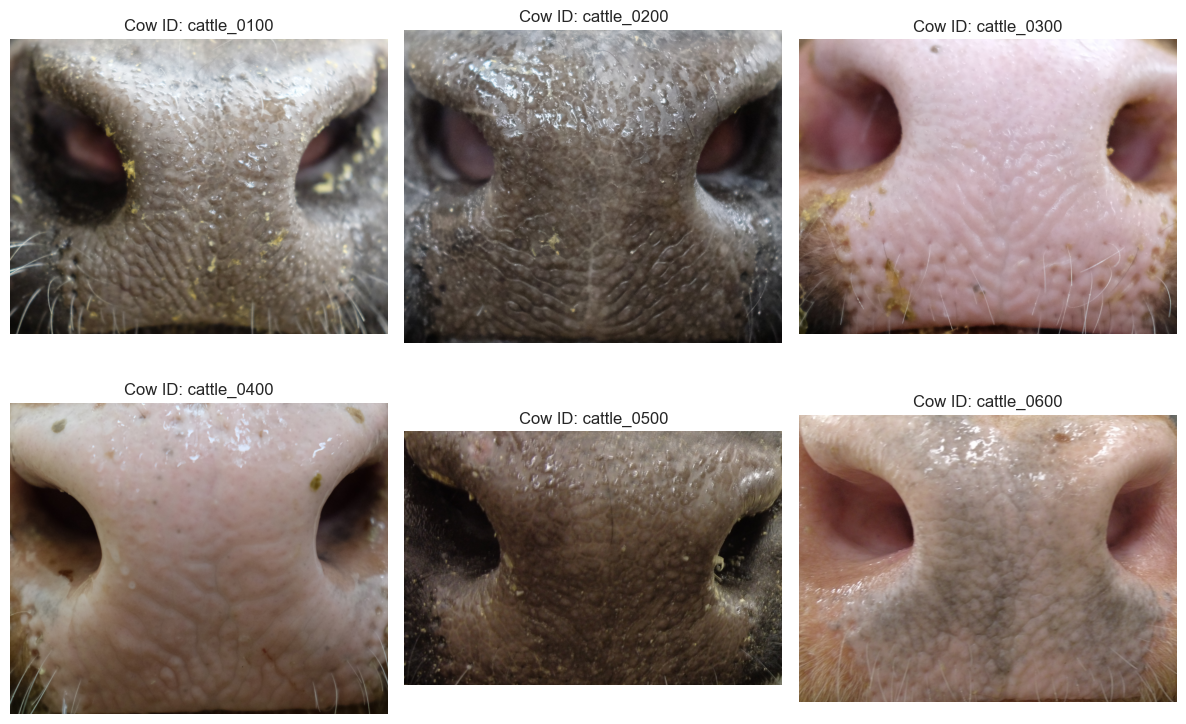

In [5]:
counts = df_cows["image_count"].tolist()
plt.figure(figsize=(10, 6))
plt.hist(counts, color="#4D96FF", edgecolor="black", bins=15)
plt.title("Distribution of Images per Cow")
plt.xlabel("Number of Images")
plt.ylabel("Number of Cows")
plt.savefig(os.path.join(eda_folder, "image_distribution_histogram.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Displaying sample muzzle prints:")
unique_cows = df_cows["cattle_id"].unique()
sample_cows = unique_cows[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, cow in enumerate(sample_cows):
    cow_files = df_images[df_images["cattle_id"] == cow]
    sample_img_path = cow_files.iloc[0]["filepath"]
    img = Image.open(sample_img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"Cow ID: {cow}")
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(eda_folder, "sample_cattle_muzzles.png"), dpi=300, bbox_inches="tight")
plt.show()

## 5. Threshold Separation & Exporting to CSV

In [6]:
threshold = 10
df_cows["status"] = df_cows["image_count"].apply(lambda x: "known" if x >= threshold else "unknown")

known_df = df_cows[df_cows["status"] == "known"]
unknown_df = df_cows[df_cows["status"] == "unknown"]

known_df.to_csv(os.path.join(eda_folder, "known_cows.csv"), index=False)
unknown_df.to_csv(os.path.join(eda_folder, "unknown_cows.csv"), index=False)

print("=" * 60)
print(f"THRESHOLD RESULTS (Threshold = {threshold} images)")
print("=" * 60)
print("Total Known Cattle:  ", len(known_df), "cows")
print("Total Unknown Cattle:", len(unknown_df), "cows")
print("Known Cattle Images:  ", df_images[df_images["cattle_id"].isin(known_df["cattle_id"])].shape[0], "images")
print("Unknown Cattle Images:", df_images[df_images["cattle_id"].isin(unknown_df["cattle_id"])].shape[0], "images")
print("Total Dataset Images: ", len(df_images), "images")
print("=" * 60)

print("\nUnknown Cattle and corresponding image counts:")
if len(unknown_df) > 0:
    for idx, row in unknown_df.iterrows():
        print(f"Cow {row['cattle_id']}: {row['image_count']} images")
else:
    print("No cows have less than 10 images in this dataset configuration.")

print("\nSuccessfully exported 'known_cows.csv' and 'unknown_cows.csv'.")
print("\nRe-importing and printing 'known_cows.csv' preview:")
preview_df = pd.read_csv(os.path.join(eda_folder, "known_cows.csv"))
print(preview_df.head(10))

print("\nRe-importing and printing 'unknown_cows.csv' preview:")
if len(unknown_df) > 0:
    preview_unk = pd.read_csv(os.path.join(eda_folder, "unknown_cows.csv"))
    print(preview_unk.head(10))
else:
    print("unknown_cows.csv is empty (0 unknown cows).")

THRESHOLD RESULTS (Threshold = 10 images)
Total Known Cattle:   227 cows
Total Unknown Cattle: 41 cows
Known Cattle Images:   4656 images
Unknown Cattle Images: 267 images
Total Dataset Images:  4923 images

Unknown Cattle and corresponding image counts:
Cow cattle_0100: 8 images
Cow cattle_0400: 7 images
Cow cattle_1500: 6 images
Cow cattle_1900: 8 images
Cow cattle_2100: 4 images
Cow cattle_2200: 6 images
Cow cattle_2220: 6 images
Cow cattle_2740: 8 images
Cow cattle_2930: 6 images
Cow cattle_3400: 7 images
Cow cattle_3420: 4 images
Cow cattle_3802: 8 images
Cow cattle_4259: 6 images
Cow cattle_4399: 7 images
Cow cattle_4451: 7 images
Cow cattle_4549: 4 images
Cow cattle_4717: 5 images
Cow cattle_4995: 6 images
Cow cattle_5100: 8 images
Cow cattle_5143: 9 images
Cow cattle_5153: 5 images
Cow cattle_5208: 4 images
Cow cattle_5234: 8 images
Cow cattle_5282: 6 images
Cow cattle_5355: 4 images
Cow cattle_5477: 9 images
Cow cattle_5556: 8 images
Cow cattle_5630: 4 images
Cow cattle_5762: 

## 6. Duplicate Image Detection

In [7]:
def check_duplicates(df):
    hashes = {}
    duplicates = []
    for idx, row in df.iterrows():
        with open(row["filepath"], "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        if h in hashes:
            duplicates.append((row["filepath"], hashes[h]))
        else:
            hashes[h] = row["filepath"]
    return duplicates

dups = check_duplicates(df_images)
print(f"Total duplicate image files detected: {len(dups)}")
if len(dups) > 0:
    for d in dups:
        print(f"Duplicate: {d[0]} is identical to {d[1]}")

Total duplicate image files detected: 0


## 7. Split Dataset Summary & Exporting Split Mappings

In [8]:
df_split_export = pd.DataFrame({
    "filepath": df_images["filepath"],
    "split": df_images["original_split"]
})
df_split_export.to_csv(os.path.join(eda_folder, "muzzle_dataset_split.csv"), index=False)
print("Successfully exported 'muzzle_dataset_split.csv'.")

train_imgs = df_images[df_images["original_split"] == "train"]
val_imgs = df_images[df_images["original_split"] == "val"]
test_imgs = df_images[df_images["original_split"] == "test"]

print("Train Images :", len(train_imgs))
print("Validation Images :", len(val_imgs))
print("Test Images :", len(test_imgs))
print("Total Split Images :", len(df_images))

total_imgs = len(df_images)
print("Train % :", round(len(train_imgs) / total_imgs * 100, 2))
print("Validation % :", round(len(val_imgs) / total_imgs * 100, 2))
print("Test % :", round(len(test_imgs) / total_imgs * 100, 2))

train_classes = train_imgs["cattle_id"].nunique()
val_classes = val_imgs["cattle_id"].nunique()
test_classes = test_imgs["cattle_id"].nunique()

print("Train Classes:", train_classes)
print("Val Classes:", val_classes)
print("Test Classes:", test_classes)

known_cow_ids = known_df["cattle_id"].tolist()
unknown_cow_ids = unknown_df["cattle_id"].tolist()
known_images_count = df_images[df_images["cattle_id"].isin(known_cow_ids)].shape[0]
unknown_images_count = df_images[df_images["cattle_id"].isin(unknown_cow_ids)].shape[0]

summary_threshold = f"""Threshold: 10

Known Cattle IDs: {len(known_df)}
Unknown Cattle IDs: {len(unknown_df)}

Known Images: {known_images_count}
Unknown Images: {unknown_images_count}

Total Cattle IDs: {len(known_df) + len(unknown_df)}
Total Images: {known_images_count + unknown_images_count}
"""

with open(os.path.join(eda_folder, "threshold_split_summary.txt"), "w") as f:
    f.write(summary_threshold)
print("threshold_split_summary.txt saved successfully.")

train_known_classes = train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()
val_known_classes = val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()
test_known_classes = test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)]["cattle_id"].nunique()

summary_split = f"""Known Cattle Split Summary

Known IDs: {len(known_df)}
Known Images: {known_images_count}

Train Classes: {train_known_classes}
Validation Classes: {val_known_classes}
Test Classes: {test_known_classes}

Train Images: {len(train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)])}
Validation Images: {len(val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)])}
Test Images: {len(test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)])}

Train Percentage: {round(len(train_imgs[train_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
Validation Percentage: {round(len(val_imgs[val_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
Test Percentage: {round(len(test_imgs[test_imgs["cattle_id"].isin(known_cow_ids)]) / known_images_count * 100, 2)}%
"""

with open(os.path.join(eda_folder, "known_split_summary.txt"), "w") as f:
    f.write(summary_split)
print("known_split_summary.txt saved successfully.")

Successfully exported 'muzzle_dataset_split.csv'.
Train Images : 3164
Validation Images : 582
Test Images : 1177
Total Split Images : 4923
Train % : 64.27
Validation % : 11.82
Test % : 23.91
Train Classes: 227
Val Classes: 227
Test Classes: 268
threshold_split_summary.txt saved successfully.
known_split_summary.txt saved successfully.


## 8. Split Representation Integrity Analysis

In [9]:
missing_train = []
missing_val = []
missing_test = []

for cow in known_cow_ids:
    if cow not in train_imgs["cattle_id"].values:
        missing_train.append(cow)
    if cow not in val_imgs["cattle_id"].values:
        missing_val.append(cow)
    if cow not in test_imgs["cattle_id"].values:
        missing_test.append(cow)

print("Split Representation Integrity Check:")
print(f"Known cows represented in ALL 3 splits (Train, Val, Test): {len(known_df) - len(set(missing_train + missing_val + missing_test))}")
print(f"Known cows missing from Train: {len(missing_train)}")
print(f"Known cows missing from Validation: {len(missing_val)}")
print(f"Known cows missing from Test: {len(missing_test)}")

Split Representation Integrity Check:
Known cows represented in ALL 3 splits (Train, Val, Test): 227
Known cows missing from Train: 0
Known cows missing from Validation: 0
Known cows missing from Test: 0


## 9. Custom PyTorch Dataset with CLAHE Preprocessing and Augmentation

Here we create a custom PyTorch Dataset class that performs the following steps:
1. Reads each image and converts BGR to RGB space.
2. Converts the RGB image to the YCrCb color space using OpenCV.
3. Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) only to the Y (luminance) channel (Clip Limit: 3.0, Tile Grid Size: (8,8)).
4. Merges the channels and converts back to RGB color space.
5. Applies data augmentation only to the training split.

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Created datasets successfully:
- Train Dataset: 3164 samples
- Validation Dataset: 582 samples
- Test Dataset: 1177 samples


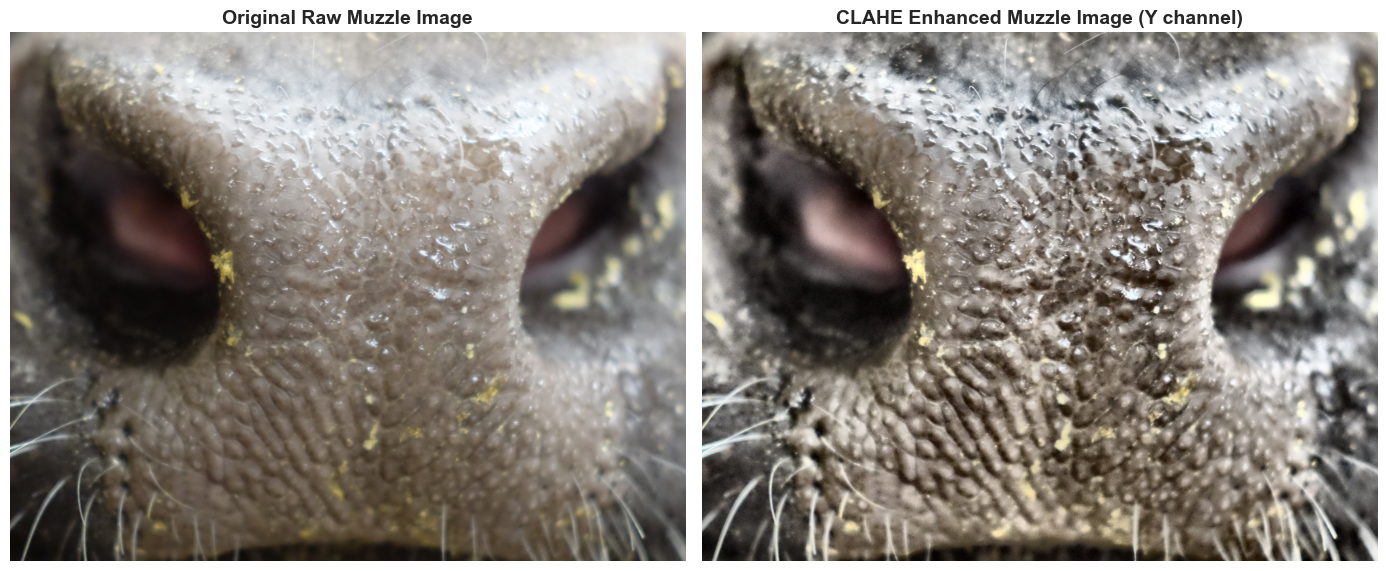

In [10]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

class CattleMuzzleDataset(Dataset):
    def __init__(self, df_records, transform=None):
        """
        df_records: DataFrame containing 'filepath' and 'cattle_id' columns
        transform: torchvision transforms to apply after CLAHE
        """
        self.filepaths = df_records['filepath'].values
        self.labels = df_records['cattle_id'].values
        self.transform = transform
        
        # Map cattle_id strings to integer class indices
        self.unique_labels = sorted(list(set(self.labels)))
        self.label_to_idx = {label: idx for idx, label in enumerate(self.unique_labels)}
        
    def __len__(self):
        return len(self.filepaths)
        
    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label_name = self.labels[idx]
        label = self.label_to_idx[label_name]
        
        # Read image using OpenCV (BGR format)
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            img_bgr = np.zeros((224, 224, 3), dtype=np.uint8)
            
        # Convert from BGR to RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Convert RGB to YCrCb space using OpenCV
        img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
        
        # Split channels into Y, Cr, Cb
        y, cr, cb = cv2.split(img_ycrcb)
        
        # Apply Contrast Limited Adaptive Histogram Equalization (CLAHE) only to the Y (luminance) channel
        # Clip Limit: 3.0, Tile Grid Size: (8, 8)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        y_enhanced = clahe.apply(y)
        
        # Merge channels back
        ycrcb_enhanced = cv2.merge((y_enhanced, cr, cb))
        
        # Convert the image back to the RGB color space
        img_enhanced_rgb = cv2.cvtColor(ycrcb_enhanced, cv2.COLOR_YCrCb2RGB)
        
        # Convert to PIL Image for torchvision transforms
        img_pil = Image.fromarray(img_enhanced_rgb)
        
        # Apply transformations (data augmentation on training, resize/tensor conversion on validation/test)
        if self.transform:
            img_tensor = self.transform(img_pil)
        else:
            default_trans = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor()
            ])
            img_tensor = default_trans(img_pil)
            
        return img_tensor, label

# Define training data augmentation (applied after CLAHE enhancement)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define validation/test transforms (No data augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Instantiate datasets
train_dataset = CattleMuzzleDataset(train_imgs, transform=train_transform)
val_dataset = CattleMuzzleDataset(val_imgs, transform=val_test_transform)
test_dataset = CattleMuzzleDataset(test_imgs, transform=val_test_transform)

print(f"Created datasets successfully:")
print(f"- Train Dataset: {len(train_dataset)} samples")
print(f"- Validation Dataset: {len(val_dataset)} samples")
print(f"- Test Dataset: {len(test_dataset)} samples")

# Visual representation of original raw image vs CLAHE enhanced image
sample_record = df_images.iloc[0]
sample_path = sample_record['filepath']

# Load original image (OpenCV BGR -> RGB)
img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Apply CLAHE pipeline
img_ycrcb = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
y, cr, cb = cv2.split(img_ycrcb)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
y_enhanced = clahe.apply(y)
ycrcb_enhanced = cv2.merge((y_enhanced, cr, cb))
img_enhanced_rgb = cv2.cvtColor(ycrcb_enhanced, cv2.COLOR_YCrCb2RGB)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Raw Muzzle Image", fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_enhanced_rgb)
axes[1].set_title("CLAHE Enhanced Muzzle Image (Y channel)", fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('clahe_muzzle_comparison.png', dpi=300)
plt.show()
